In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import math

2026-06-25 14:01:10.144193: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-25 14:01:10.460622: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-25 14:01:12.674986: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Model

In [ ]:
# Kernel initializer to use
def kernel_init(scale):
    scale = max(scale, 1e-10)
    return tf.keras.initializers.VarianceScaling(
        scale, mode="fan_avg", distribution="uniform"
    )


class AttentionBlock(layers.Layer):
    
    def __init__(self, units, groups=8, **kwargs):
        self.units = units
        self.groups = groups
        super().__init__(**kwargs)

        self.norm = layers.GroupNormalization(groups=groups)
        self.query = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.key = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.value = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.proj = layers.Dense(units, kernel_initializer=kernel_init(0.0))

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        scale = tf.cast(self.units, tf.float32) ** (-0.5)

        inputs = self.norm(inputs)
        q = self.query(inputs)
        k = self.key(inputs)
        v = self.value(inputs)

        attn_score = tf.einsum("bhwc, bHWc->bhwHW", q, k) * scale
        attn_score = tf.reshape(attn_score, [batch_size, height, width, height * width])

        attn_score = tf.nn.softmax(attn_score, -1)
        attn_score = tf.reshape(attn_score, [batch_size, height, width, height, width])

        proj = tf.einsum("bhwHW,bHWc->bhwc", attn_score, v)
        proj = self.proj(proj)
        return inputs + proj


class TimeEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.half_dim = dim // 2    
        self.emb = math.log(10000) / (self.half_dim - 1)
        self.emb = tf.exp(tf.range(self.half_dim, dtype=tf.float32) * -self.emb)

    def call(self, inputs):
        inputs = tf.cast(inputs, dtype=tf.float32)
        emb = inputs[:, None] * self.emb[None, :]
        emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)
        return emb

def encoder_block(inputs, num_filters, time_emb_inp):
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same", activation="swish")(inputs)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same", activation="swish")(x)

    time_emb = tf.keras.layers.Dense(num_filters)(time_emb_inp)
    time_emb = tf.reshape(time_emb, [-1, 1, 1, num_filters]) # maybe [-1,1,1,1,num_filters] cuz of RGBA
    x = x + time_emb

    skip = x

    x = tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=2)(x)

    return x, skip

def decoder_block(inputs, skip_features, num_filters, time_emb_inp):
    x = tf.keras.layers.UpSampling2D(size=(2,2))(inputs)
    x = tf.keras.layers.Concatenate()([x, skip_features])

    skip_features = tf.keras.layers.Reshape(x.shape[1], x.shape[2])(skip_features)

    x = tf.keras.layers.Concatenate([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same")(inputs)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same")(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

def unet_model(input_shape=(64, 64, 4), num_classes=1):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Contracting Path (Encoder)
    s1 = encoder_block(inputs, 64)
    s2 = encoder_block(s1, 128)
    s3 = encoder_block(s2, 256)
    s4 = encoder_block(s3, 512)
    
    # Bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(s4)
    b1 = tf.keras.layers.Activation('relu')(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(b1)
    b1 = tf.keras.layers.Activation('relu')(b1)
    
    # Expansive Path (Decoder)
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    outputs = tf.keras.layers.Conv2D(num_classes, 1, padding='same', activation='sigmoid')(d4)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model

# Dataset

2026-06-25 14:01:16.459445: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Caption: The image features a character that is reminiscent of those found in sandbox video games, specifically one from the "Minecraft" series. The character has a blocky, pixelated design typical of this game's aesthetic. It appears to be wearing a green shirt with white sleeves and blue shorts with white stars, which could suggest a casual or adventurous theme. The brown hair adds a touch of realism to the otherwise stylized figure. Given the simplicity and the iconic nature of the design, it is likely intended to represent a generic player avatar within the game rather than an individual with specific personal characteristics.


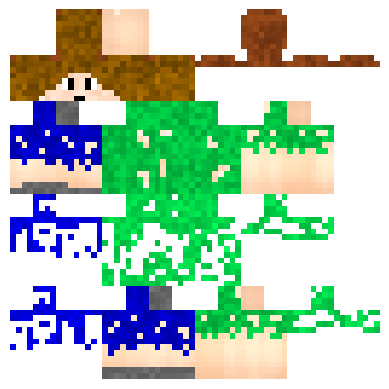

Caption: The image depicts a video game character that appears to be designed with a blocky, pixelated art style commonly associated with sandbox or adventure games. The character's white head is reminiscent of a skull, which could suggest a theme related to danger, mystery, or a supernatural element within the game's narrative. The black outfit with red and pink accents might indicate a role such as a villain, anti-hero, or someone with special abilities. The colorful stripes at the bottom of the legs add a touch of vibrancy and could signify movement or energy. This character design is likely intended to stand out in-game due to its distinctive color scheme and unique appearance compared to more traditionally styled characters.


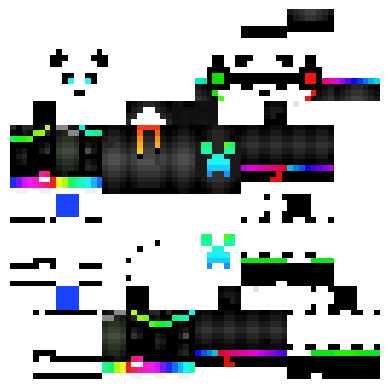

Caption: The image depicts a character that appears to be from a video game, specifically one with a pixelated art style reminiscent of early 2000s or retro gaming aesthetics. The character is dressed in what seems to be a combat uniform, which includes a green helmet and a jacket with various colors like brown, yellow, and gray, suggesting it could be designed for camouflage or field operations. The attire indicates that the character might be involved in military or tactical scenarios within the game's narrative. The pixelation of the image suggests that the character is likely not intended for high-resolution graphics but rather for a more stylized, blocky visual representation typical of certain genres of games such as role-playing games (RPGs), action-adventure games, or possibly sandbox-style games where customization and personalization are key elements.


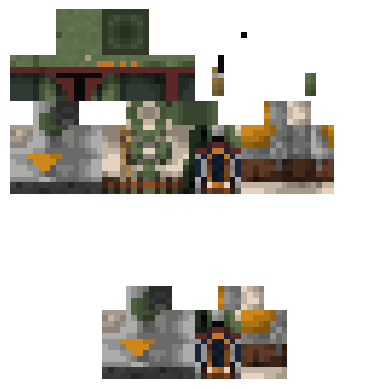

2026-06-25 14:01:18.518125: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import glob

def decode_fn(file):
    schema = {
        "image":tf.io.FixedLenFeature([], dtype=tf.string),
        "caption":tf.io.FixedLenFeature([], dtype=tf.string)
    }
    
    parsed = tf.io.parse_single_example(file, schema)
    image = tf.io.decode_image(parsed["image"], channels=4, dtype=tf.uint8)
    image= tf.cast(image, tf.float32) / 127.5 - 1
    image = tf.reshape(image, [64,64,4])
    caption = parsed["caption"]

    return (image, caption)

files = glob.glob("../Datasets/minecraft_tfrecords/*.tfrecord")

dataset = tf.data.TFRecordDataset(files)\
    .map(decode_fn, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(64, drop_remainder=True)\
    .prefetch(tf.data.AUTOTUNE)\
    .shuffle(1000)

for img, cap in dataset.take(1):
    for i in range(3):
        print(f"Caption: {cap.numpy()[i].decode('utf-8')}")
        plt.imshow(tf.reshape(img[i], (64,64,4)) / 2 + 0.5)
        plt.axis('off')
        plt.show()